# 06 - Trees, Homework

## Step 1 - Preparing the data
- Read data
- Fill NA values
- Split data
- Create feature matrices

In [78]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer

from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import export_graphviz, export_text

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error as mse

from matplotlib import pyplot as plt

from tqdm import tqdm

In [20]:
data = "/workspaces/ml-zoomcamp/data/car_fuel_efficiency.csv"
df = pd.read_csv(data)
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [21]:
df.dtypes

engine_displacement      int64
num_cylinders          float64
horsepower             float64
vehicle_weight         float64
acceleration           float64
model_year               int64
origin                  object
fuel_type               object
drivetrain              object
num_doors              float64
fuel_efficiency_mpg    float64
dtype: object

In [22]:
# num_cylinders, horsepower, acceleration, and num_doors all have null values

df.isnull().sum()

engine_displacement      0
num_cylinders          482
horsepower             708
vehicle_weight           0
acceleration           930
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors              502
fuel_efficiency_mpg      0
dtype: int64

In [23]:
features_null = ["num_cylinders", "horsepower", "acceleration", "num_doors"]
for feature in features_null:
    df[feature] = df[feature].fillna(0.0)

In [24]:
df.isnull().sum()

engine_displacement    0
num_cylinders          0
horsepower             0
vehicle_weight         0
acceleration           0
model_year             0
origin                 0
fuel_type              0
drivetrain             0
num_doors              0
fuel_efficiency_mpg    0
dtype: int64

In [25]:
# Next, prepare train, val, test sets
n = 0.2
SEED = 1

In [26]:
df_full_train, df_test = train_test_split(df, test_size=n, random_state=SEED)
df_train, df_val = train_test_split(df_full_train, test_size=n/(1-n), random_state=SEED)

In [27]:
df_full_train.shape, df_train.shape, df_val.shape, df_test.shape

((7763, 11), (5822, 11), (1941, 11), (1941, 11))

In [28]:
df_full_train = df_full_train.reset_index(drop=True)
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [29]:
y_full_train = df_full_train["fuel_efficiency_mpg"]
y_train = df_train["fuel_efficiency_mpg"]
y_val = df_val["fuel_efficiency_mpg"]
y_test = df_test["fuel_efficiency_mpg"]

In [30]:
del df_full_train["fuel_efficiency_mpg"]
del df_train["fuel_efficiency_mpg"]
del df_val["fuel_efficiency_mpg"]
del df_test["fuel_efficiency_mpg"]

In [32]:
dv = DictVectorizer(sparse=False)

In [33]:
dicts_train = df_train.to_dict(orient="records")
dicts_val = df_val.to_dict(orient="records")

In [35]:
X_train = dv.fit_transform(dicts_train)
X_val = dv.transform(dicts_val)

## **Question 1**
- Train a Decision Tree Regressor model
- Answer: **vehicle_weight** was used to split the data

In [43]:
dt = DecisionTreeRegressor(max_depth=1)

In [45]:
dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [51]:
print(export_text(dt, feature_names=dv.get_feature_names_out()))

|--- vehicle_weight <= 3022.11
|   |--- value: [16.88]
|--- vehicle_weight >  3022.11
|   |--- value: [12.94]



## **Question 2**
- Train a random forest model
- Answer: RMSE = **0.45**

In [53]:
RandomForestRegressor?

Init signature:
RandomForestRegressor(
    n_estimators=100,
    *,
    criterion='squared_error',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features=1.0,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    bootstrap=True,
    oob_score=False,
    n_jobs=None,
    random_state=None,
    verbose=0,
    warm_start=False,
    ccp_alpha=0.0,
    max_samples=None,
    monotonic_cst=None,
)
Docstring:     
A random forest regressor.

A random forest is a meta estimator that fits a number of decision tree
regressors on various sub-samples of the dataset and uses averaging to
improve the predictive accuracy and control over-fitting.
Trees in the forest use the best split strategy, i.e. equivalent to passing
`splitter="best"` to the underlying :class:`~sklearn.tree.DecisionTreeRegressor`.
The sub-sample size is controlled with the `max_samples` parameter if
`bootstrap=True` (default), otherwise the whole dataset is use

In [56]:
n_estimators = 10
n_jobs=-1

rf = RandomForestRegressor(n_estimators=n_estimators, n_jobs=n_jobs, random_state=SEED)

In [57]:
rf.fit(X_train, y_train)

,n_estimators,10
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [60]:
y_pred_rf = rf.predict(X_val)
y_pred_rf

array([18.62889858, 15.29598647, 18.22879442, ..., 14.80283652,
       13.49358341, 15.99288211], shape=(1941,))

In [65]:
rmse = np.sqrt(mse(y_val, y_pred_rf))
rmse

np.float64(0.4599777557336148)

## **Question 3**
- Experimenting with different n_estimators for Random Forest
- Answer: We still see marginal increases around and above n_estimators=**200**

In [75]:
n_estimators = np.arange(10, 401, 20)
n_estimators

array([ 10,  30,  50,  70,  90, 110, 130, 150, 170, 190, 210, 230, 250,
       270, 290, 310, 330, 350, 370, 390])

In [76]:
scores = []

for n in tqdm(n_estimators):
    rf = RandomForestRegressor(n_estimators=n, n_jobs=n_jobs, random_state=SEED)
    rf.fit(X_train, y_train)

    y_pred_rf = rf.predict(X_val)
    rmse = np.sqrt(mse(y_val, y_pred_rf))

    scores.append([n, rmse])


100%|██████████| 20/20 [01:27<00:00,  4.36s/it]


In [77]:
scores_df = pd.DataFrame(data=scores, columns=["n_estimators", "rmse"])
scores_df.round(4)

,n_estimators,rmse
0,10,0.4600
1,30,0.4507
2,50,0.4462
3,70,0.4446
4,90,0.4447
5,110,0.4431
6,130,0.4434
7,150,0.4429
8,170,0.4427
9,190,0.4426


Text(0, 0.5, 'rmse')

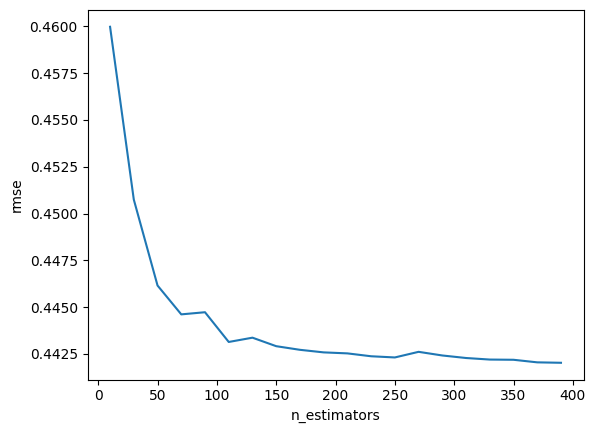

In [83]:
plt.plot(scores_df["n_estimators"], scores_df["rmse"])

plt.xlabel("n_estimators")
plt.ylabel("rmse")

## **Question 4**
- Train for different max_depths
- The best result is from max_depth=**10**

In [ ]:
max_depths = [10, 15, 20, 25]

scores = []

for n in tqdm(n_estimators):
    for d in max_depths:
        rf = RandomForestRegressor(n_estimators=n, max_depth=d, random_state=1)

        rf.fit(X_train, y_train)

        y_pred = rf.predict(X_val)

        rmse = np.sqrt(mse(y_val, y_pred))

        scores.append([n, d, rmse])

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [07:24<00:00, 22.20s/it]


In [88]:
df_scores = pd.DataFrame(data=scores, columns=["n_estimators", "max_depth", "rmse"])
df_scores

,n_estimators,max_depth,rmse
0,10,10,0.455877
1,10,15,0.462576
2,10,20,0.468407
3,10,25,0.469960
4,30,10,0.444864
...,...,...,...
75,370,25,0.442677
76,390,10,0.439922
77,390,15,0.442787
78,390,20,0.443756


In [90]:
df_scores[df_scores["max_depth"] == 10]

,n_estimators,max_depth,rmse
0,10,10,0.455877
4,30,10,0.444864
8,50,10,0.443934
12,70,10,0.442706
16,90,10,0.442744
20,110,10,0.442089
24,130,10,0.440633
28,150,10,0.440516
32,170,10,0.439944
36,190,10,0.441329


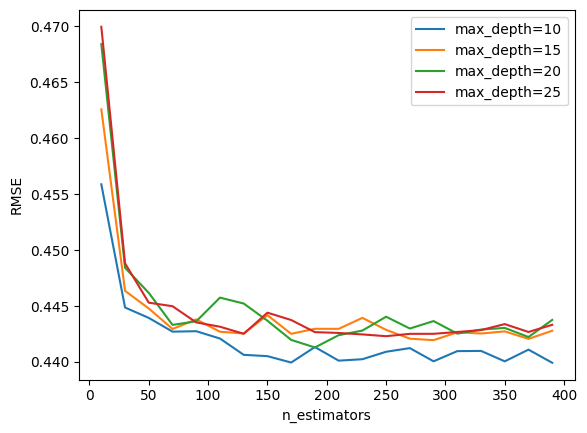

In [93]:
for d in max_depths:
    x = df_scores[df_scores["max_depth"] == d].n_estimators
    y = df_scores[df_scores["max_depth"] == d].rmse
    plt.plot(x, y, label=f"max_depth={d}")
plt.xlabel("n_estimators")
plt.ylabel("RMSE")
plt.legend()

## **Question 5**
- 

In [94]:
RandomForestRegressor?

Init signature:
RandomForestRegressor(
    n_estimators=100,
    *,
    criterion='squared_error',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    min_weight_fraction_leaf=0.0,
    max_features=1.0,
    max_leaf_nodes=None,
    min_impurity_decrease=0.0,
    bootstrap=True,
    oob_score=False,
    n_jobs=None,
    random_state=None,
    verbose=0,
    warm_start=False,
    ccp_alpha=0.0,
    max_samples=None,
    monotonic_cst=None,
)
Docstring:     
A random forest regressor.

A random forest is a meta estimator that fits a number of decision tree
regressors on various sub-samples of the dataset and uses averaging to
improve the predictive accuracy and control over-fitting.
Trees in the forest use the best split strategy, i.e. equivalent to passing
`splitter="best"` to the underlying :class:`~sklearn.tree.DecisionTreeRegressor`.
The sub-sample size is controlled with the `max_samples` parameter if
`bootstrap=True` (default), otherwise the whole dataset is use